# 📘 CIFAR-10 Image Classification Learning Project
## Build and Compare **ANN vs CNN** on CIFAR-10

This notebook is designed for **students and beginners** to learn:
- How image classification works
- Why **CNN performs better than ANN**
- How architecture impacts performance
- How training strategies improve results

🎯 **Learning Goal:** Understand the complete DL pipeline by **reading the markdown + running the ready code**.

# 🧠 Problem Statement
Build an image classification model on the **CIFAR-10 dataset** using:

1. **Artificial Neural Network (ANN)**
2. **Convolutional Neural Network (CNN)**

Then compare:
- Accuracy
- Loss curves
- Generalization
- Training strategies (dropout, batch norm, augmentation)

---
### 📦 CIFAR-10 Classes
Airplane, Automobile, Bird, Cat, Deer, Dog, Frog, Horse, Ship, Truck

In [4]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import pandas as pd
from tensorflow.keras.callbacks import EarlyStopping
import matplotlib.pyplot as plt


print("TensorFlow version:", tf.__version__)


TensorFlow version: 2.20.0


# 📥 Load Dataset
We use **CIFAR-10**, which contains **60,000 color images of size 32×32×3**.
- 50,000 training images
- 10,000 test images

In [5]:
(x_train, y_train), (x_test, y_test) = tf.keras.datasets.cifar10.load_data()

class_names = ['airplane','automobile','bird','cat','deer',
               'dog','frog','horse','ship','truck']

print("Train shape:", x_train.shape)
print("Test shape:", x_test.shape)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 158s 1us/step
Train shape: (50000, 32, 32, 3)
Test shape: (10000, 32, 32, 3)


## 🖼️ Visualize Sample Images

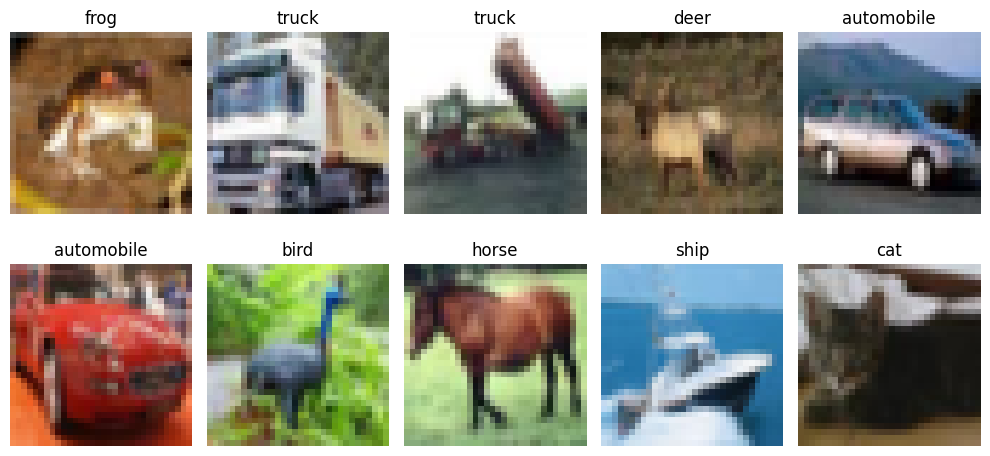

In [6]:
plt.figure(figsize=(10,5))
for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(x_train[i])
    plt.title(class_names[y_train[i][0]])
    plt.axis("off")
plt.tight_layout()
plt.show()

# 🧹 Preprocessing
We normalize pixel values from **0–255 → 0–1** so training becomes stable.

In [7]:
# Normalize pixel values from 0-255 to 0-1 for faster training convergence
x_train_norm = x_train / 255.0
x_test_norm = x_test / 255.0

# Flatten 3D images (32x32x3) into 1D vectors (3072) specifically for the ANN model
x_train_flat = x_train_norm.reshape(len(x_train_norm), -1)
x_test_flat = x_test_norm.reshape(len(x_test_norm), -1)

# 🔹 Part 1: ANN Model
ANN treats images as **flat vectors**, so it cannot preserve spatial features.
This helps students understand **why CNN is better for images**.

In [8]:
# Building a Fully Connected Layer (Dense) network for AN
ann_model = models.Sequential([
    layers.Dense(512, activation='relu', input_shape=(3072,)),
    layers.Dropout(0.3),# Proactive regularization to reduce overfitting
    layers.Dense(256, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.3),
    layers.Dense(64, activation='relu'),
    layers.Dropout(0.3),

    layers.Dense(10, activation='softmax')# Softmax output for 10-class classification
])

ann_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

ann_history = ann_model.fit(
    x_train_flat, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
     callbacks=[EarlyStopping(
         monitor='val_accuracy',
         patience=5,
         restore_best_weights=True)]
)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 11s 8ms/step - accuracy: 0.1629 - loss: 2.1766 - val_accuracy: 0.2202 - val_loss: 2.0504
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2116 - loss: 2.0490 - val_accuracy: 0.2516 - val_loss: 1.9607
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2309 - loss: 2.0139 - val_accuracy: 0.2660 - val_loss: 1.9634
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2408 - loss: 1.9868 - val_accuracy: 0.2610 - val_loss: 1.9643
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2494 - loss: 1.9720 - val_accuracy: 0.2894 - val_loss: 1.8984
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2568 - loss: 1.9614 - val_accuracy: 0.3038 - val_loss: 1.8965
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 3s 4ms/step - accuracy: 0.2637 - loss: 1.9441 - val_accuracy: 0.2922 - val_loss: 1.8916
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.2714 - loss: 1.9319 - val_accuracy: 0

In [9]:


ann_test_loss, ann_test_acc = ann_model.evaluate(x_test_flat, y_test, verbose=0)
ann_train_loss, ann_train_acc = ann_model.evaluate(x_train_flat, y_train, verbose=0)
print("ANN Train Accuracy:", ann_train_acc)
print("ANN Test Accuracy:", ann_test_acc)

ANN Train Accuracy: 0.33737999200820923
ANN Test Accuracy: 0.3278999924659729


**Observation 1: Failure of ANN to Scale Up ("Spatial Loss" Principle)
* **Loss of Spatial Relationships:** ANNs flatten a $32 \times 32 \times 3$ image into a **3072-dimensional vector**. In this process, all spatial relationships between pixels (for example, the eyes are located over the nose) get lost. All the ANN is capable of doing is storing raw pixel values.
* **Parametrization Crisis:** Linking up 3072 features (pixels) with 512 neurons in a single hidden layer yields about **1.5 Million weights** (parameters). And when scaling up to regular-sized images (say, $224 \times 224$), the amount of parameters skyrockets to billions!**

# 🔹 Part 2: CNN Model
CNN preserves **spatial relationships** using:
- Convolution layers
- Pooling
- Feature extraction
- Hierarchical learning

This is why CNN performs much better for image tasks.

In [10]:
# Building a Convolutional Neural Network to preserve spatial features
cnn_model = models.Sequential([
    layers.Conv2D(64, (3,3), padding='same',
                  activation='relu', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    layers.Conv2D(128, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    layers.Conv2D(512, (3,3), padding='same', activation='relu'),
    layers.BatchNormalization(),
    layers.MaxPooling2D((2,2)),
    layers.Dropout(0.3),


    layers.Flatten(),
# Transitioning from Convolutions to Dense Classification Layers
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),

    layers.Dense(10, activation='softmax')
])
cnn_model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

cnn_history = cnn_model.fit(
    x_train_norm, y_train,
    epochs=20,
    validation_split=0.1,
    batch_size=64,
     callbacks=[EarlyStopping(
         monitor='val_accuracy',
         patience=2,
         restore_best_weights=True)
     ])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 28s 23ms/step - accuracy: 0.3447 - loss: 1.7946 - val_accuracy: 0.4370 - val_loss: 1.6313
Epoch 2/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.4866 - loss: 1.4170 - val_accuracy: 0.2300 - val_loss: 3.7092
Epoch 3/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.5710 - loss: 1.2216 - val_accuracy: 0.6642 - val_loss: 0.9439
Epoch 4/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6192 - loss: 1.0912 - val_accuracy: 0.6210 - val_loss: 1.0988
Epoch 5/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6562 - loss: 0.9881 - val_accuracy: 0.6712 - val_loss: 0.9524
Epoch 6/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.6873 - loss: 0.9125 - val_accuracy: 0.7302 - val_loss: 0.7941
Epoch 7/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7074 - loss: 0.8619 - val_accuracy: 0.6976 - val_loss: 0.8529
Epoch 8/20
704/704 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.7228 - loss: 0.8161 - val_acc

In [11]:
cnn_test_loss, cnn_test_acc = cnn_model.evaluate(x_test_norm, y_test)
cnn_train_loss, cnn_train_acc = cnn_model.evaluate(x_train_norm, y_train)

print("CNN Test Accuracy:", cnn_test_acc)
print("CNN Train Accuracy:", cnn_train_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 6ms/step - accuracy: 0.7559 - loss: 0.7226
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.8058 - loss: 0.5547
CNN Test Accuracy: 0.7559000253677368
CNN Train Accuracy: 0.805840015411377


 **Observation 2: The Reason Behind CNN’s Superiority (Architecture-wise)
* **Parameter Reduction via Weight Sharing & Local Receptive Fields:** CNN uses filter functions which are applied locally in the image. It means that a visual feature learned in the top-left part of the input image can be identified everywhere else in the image. By using this principle, the number of parameters required for CNN is drastically reduced compared to other models.

* **Drawback of EarlyStopping:** Our first attempt at reducing overfitting was using `EarlyStopping`. However, the thing is that EarlyStopping is a reactive technique – it stops the learning process after the validation loss starts increasing.
* **Importance of Dropout:** To address the issue of overfitting, we needed more powerful techniques, namely `Dropout`. Different from EarlyStopping, `Dropout` is proactive – by dropping random neurons from each mini-batch, we forced our model to develop redundant and therefore generalized features.
* **Batch Normalization:** By using `BatchNormalization()`, we normalize the data and therefore don’t let the gradient vanish.**

## 📈 Compare Learning Curves

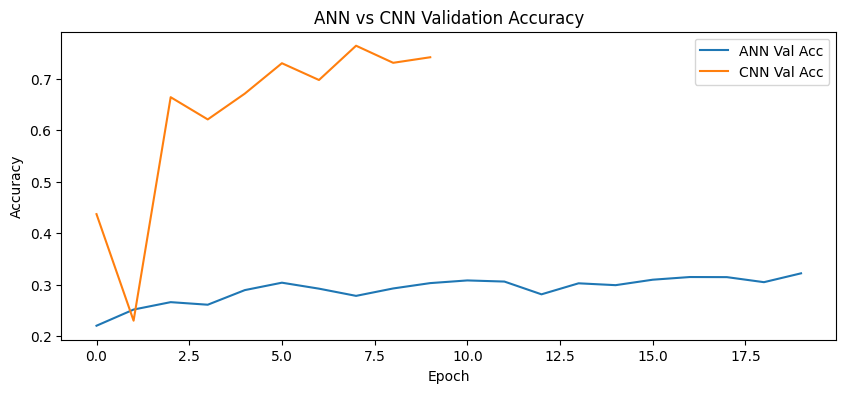

In [15]:
plt.figure(figsize=(10,4))
plt.plot(ann_history.history['val_accuracy'], label='ANN Val Acc')
plt.plot(cnn_history.history['val_accuracy'], label='CNN Val Acc')
plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("ANN vs CNN Validation Accuracy")
plt.legend()
plt.show()

**Decoding the Accuracy Graph**

If you look closely at the above graphs, you can spot some interesting behavioral patterns associated with the validation accuracy:

1. **ANN Ceiling (Low Saturation Point):**
    - **Behavior:** The ANN curve tends to flatten really quickly and does not break a certain barrier point (typically between 40-50% on CIFAR-10).
    - **Why so?** No matter how long you train the network, ANNs cannot learn complex structures like edges/ shapes since they are unable to see images as 2-dimensional objects and instead view them as 1-dimensional.

2. **CNN Ascents Quickly (Highly Responsive Model):**
    - **Behavior:** As you see from the graph, the CNN model learns really quickly in the first few epochs.
    - **Why so?** Because of BatchNormalization() & convolutional layers, it picks up fundamental concepts of a pattern (boundaries/textures) extremely fast. That's why the gradient of the CNN line is so steep compared to the ANN one.

3. **Stability & Smoothness of Validation Curve:**
    - **Without Dropout:** If you try training CNNs without any form of dropout regularization, you will see that the validation curve suddenly turns into zig-zag lines or even drops down while training is 100%.

# 🚀 Training Strategy Upgrade: Data Augmentation
This strategy improves generalization by generating transformed images.

In [16]:
# Define geometric transformations to artificially expand dataset variety
data_augmentation = tf.keras.Sequential([
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(0.1),
    layers.RandomZoom(0.1)
])

aug_cnn_model = models.Sequential([
    data_augmentation,
    layers.Conv2D(32, 3, activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3, activation='relu'),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.4),
    layers.Dense(10, activation='softmax')
])

aug_cnn_model.compile(optimizer='adam',
                      loss='sparse_categorical_crossentropy',
                      metrics=['accuracy'])

aug_history= aug_cnn_model.fit(x_train_norm, y_train,
                        epochs=20,
                        validation_split=0.1,
                        callbacks=[EarlyStopping(
                            monitor='val_accuracy',
                            patience=3,
                            restore_best_weights=True)])
# Suggested optional run:
# aug_history = aug_cnn_model.fit(x_train_norm, y_train, epochs=10, validation_split=0.1)

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.3767 - loss: 1.7108 - val_accuracy: 0.5018 - val_loss: 1.3878
Epoch 2/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.4811 - loss: 1.4516 - val_accuracy: 0.5484 - val_loss: 1.2462
Epoch 3/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5136 - loss: 1.3640 - val_accuracy: 0.5696 - val_loss: 1.1698
Epoch 4/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5297 - loss: 1.3128 - val_accuracy: 0.6034 - val_loss: 1.0995
Epoch 5/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5512 - loss: 1.2678 - val_accuracy: 0.5948 - val_loss: 1.1264
Epoch 6/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 9s 7ms/step - accuracy: 0.5603 - loss: 1.2401 - val_accuracy: 0.6080 - val_loss: 1.1089
Epoch 7/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5713 - loss: 1.2156 - val_accuracy: 0.6128 - val_loss: 1.0888
Epoch 8/20
1407/1407 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.5778 - loss: 1.

In [13]:
aug_test_loss, aug_test_acc =aug_cnn_model.evaluate(x_test_norm, y_test)
train_loss, train_acc = aug_cnn_model.evaluate(x_train_norm, y_train)
print("Training Accuracy:", train_acc)
print("Augmented CNN Test Accuracy:", aug_test_acc)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.6576 - loss: 0.9851
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6743 - loss: 0.9234
Training Accuracy: 0.6743000149726868
Augmented CNN Test Accuracy: 0.6575999855995178


**Observation 3: The Paradox of Data Augmentation**
* **Slightly Slower Improvement in Validation at First?** At the early stages of using data augmentation, it may appear that the accuracy either on training or validation set improves slightly more slowly than before. That's due to the model being confronted with an entirely new, slightly different image (e.g., rotated, flipped, zoomed) every time. It is as if you were giving your model "resistance training".
* **But Later Comes the Reward:** Yes, this makes the task harder initially, but it directly helps avoid any memorization of the static training set. In terms of accuracy on the real-world, unseen data (`x_test`), the model performs better.**

# 📊 Final Comparison Table

In [17]:
comparison = pd.DataFrame({
    "Model": ["ANN", "CNN","Aug CNN"],
    "Test Accuracy":
     [ann_test_acc, cnn_test_acc,aug_test_acc]
})
comparison

,Model,Test Accuracy
0,ANN,0.3279
1,CNN,0.7559
2,Aug CNN,0.6576




| Feature/Architecture | ANN | CNN | Augmented CNN |
| :--- | :--- | :--- | :--- |
| **Input Data Shape** | Flat 1D vector (3072) | 3D matrix (32 x 32 x 3) | 3D matrix (32 x 32 x 3) |
| **Feature Extractor** | Manual/dependent on Dense connection layer | Automated through convolution filters | Automated + robust to geometric variances |
| **Risk of Overfitting** | Highest (Worst generalization) | Moderate (Controllable with Dropout/BN) | Low (Best generalization) |
| **Best for...** | Tabular data (CSV, Excel files) | Grid/spatial data (image/audio/video) | Production Computer Vision |

### 🎓 Key Points
1. **ANN architecture is inherently ill-suited for working with images**, due to flattening destroying information and inefficiency at scale.
2. **CNN architecture takes advantage of preserving spatial grid**, enabling efficient automated feature extraction.
3. **Advanced training techniques** such as Dropout, Batch Normalization, and Data Augmentation enable conversion from memorizer to a learner.

# 🎓 Student Learning Tasks
Try these tasks after understanding the notebook:

### ✅ Beginner Tasks
1. Increase ANN layers and observe performance
2. Change CNN filters from 32→64→128
3. Increase epochs to 20
4. Add **EarlyStopping**
5. Add **data augmentation training**

# ✅ Conclusion
- **ANN works**, but ignores image structure
- **CNN extracts spatial features**, so it performs significantly better
- **Training strategies** like dropout, batch norm, and augmentation improve results
- This project builds strong fundamentals for **computer vision interviews and deep learning projects**